<a href="https://colab.research.google.com/github/qudwo9969-glitch/maritime-data-mining/blob/main/%ED%95%B4%EC%82%AC%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%A7%88%EC%9D%B4%EB%8B%9D%202026.04.08%20%EC%88%99%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

===== 데이터 크기 =====
Train Shape: (4198, 21)
Test Shape: (1499, 20)


===== 데이터 정보(자료형) =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4198 entries, 0 to 4197
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Delay_from_due_date       4198 non-null   float64
 1   Num_of_Delayed_Payment    4198 non-null   float64
 2   Num_Credit_Inquiries      4198 non-null   float64
 3   Credit_Utilization_Ratio  4198 non-null   float64
 4   Credit_History_Age        4198 non-null   float64
 5   Payment_of_Min_Amount     4198 non-null   object 
 6   Amount_invested_monthly   4198 non-null   float64
 7   Monthly_Balance           4198 non-null   float64
 8   Credit_Mix                4198 non-null   object 
 9   Payment_Behaviour         4198 non-null   object 
 10  Age                       4198 non-null   float64
 11  Annual_Income             4198 non-null   float64
 12  Num_Bank_Accounts         

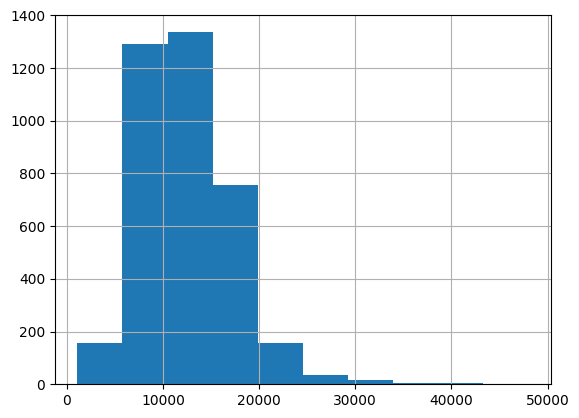

In [2]:
#1. 문제정의
# target: Crddit_Score
# (1) 예측 컬럼 : 예측해야 할 값은 어떤 컬럼인지 알려준다.
# 평가: f1-macro
# (2) 평가방식 : 문제에서 평가하고자 하는 평가지표를 알려준다. 평가지표로 검증을 진행한다.
# 분류 : 정확도(Accuracy), 정밀도(Precision), 재현율(Recall), F1 Score, ROC-AUC
# 회귀 : MSE, MAE, 결정계수(R-squared), RMSE
#최종파일: result.csv(컬럼 1개: pred)

# 2. 라이브러리 및 데이터 불러오기
import pandas as pd
# train = pd.read_csv("score_train.csv")
# test = pd.read_csv("score_test.csv")
train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part2/ch7/score_train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part2/ch7/score_test.csv")

# 3. 탐색적 데이터 분석(EDA)
# (1)데이터 크기 확인
print("===== 데이터 크기 =====")
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("\n") # 줄 바꿈

# (2)컬럼별 자료형 확인
print("===== 데이터 정보(자료형) =====")
print(train.info())
print("\n")

# 3. 탐색적 데이터 분석(EDA)
# (3)결측치 확인
print("===== train 결측치 수 =====")
print(train.isnull().sum().sum())
# 데이터프레임 전체의 결측치(NaN/Null) 개수를 하나의 숫자로 얻어내기 위함
print("\n")

print("===== test 결측치 수 =====")
print(test.isnull().sum().sum())
print("\n")

# (4)target 확인 -> 분류 group 개수 확인
print("===== target 빈도 =====")
print(train['Credit_Score'].value_counts())
# Series 객체에 적용되며, 해당 Series 내부에 있는 고유한 값(Unique Values)들의 빈도수를 계산

# 4. 데이터 전처리
# 원핫인코딩 (target컬럼이 object형이라 제외)
target = train.pop('Credit_Score')

train = pd.get_dummies(train)
test = pd.get_dummies(test)

# 5. 검증 데이터 분할
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(train, target, test_size=0.2, random_state=0)

print("\n ===== 분할된 데이터 크기 =====")
print(X_tr.shape, X_val.shape, y_tr.shape, y_val.shape)

# 6. 머신러닝 학습 및 평가
# 분류를 위한 지도학습에서 데이터를 학습시키고 예측하는 가장 기본적인 Scikit-learn 표준 파이프라인으로 랜덤 포레스트 분류기(RandomForestClassifier) 모델을 사용함.
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=0)
rf.fit(X_tr, y_tr)
pred = rf.predict(X_val)

from sklearn.metrics import f1_score
f1 = f1_score(y_val, pred, average='macro')
print('\n f1-macro:', f1)

# 7. 예측 및 결과 파일 생성
pred = rf.predict(test)
submit = pd.DataFrame({'pred':pred})
submit.to_csv("result.csv", index=False)

# 제출파일 확인
print("\n ===== 제출파일 (샘플 5개) =====")
print(pd.read_csv("result.csv").head())

# 데이터 불러오기
import pandas as pd
# train = pd.read_csv("train.csv")
# test = pd.read_csv("test.csv")
train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part4/ch5/train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part4/ch5/test.csv")

# 3. 탐색적 데이터 분석(EDA)

# 데이터 크기 확인
train.shape, test.shape

# ((3759, 9), (1617, 8))

# 샘플 확인
train.head(3)

# model	year	price	transmission	mileage	fuelType	tax	mpg	engineSize
# 0	EcoSport	2017	10298	Manual	25013	Petrol	150	53.3	1.0
# 1	Focus	2016	10491	Manual	30970	Diesel	0	74.3	1.5
# 2	S-MAX	2017	13498	Manual	60200	Diesel	150	56.5	2.0

test.head(3)

# model	year	transmission	mileage	fuelType	tax	mpg	engineSize
# 0	S-MAX	2016	Manual	23905	Diesel	125	56.5	2.0
# 1	Fiesta	2018	Manual	16895	Petrol	145	40.3	1.5
# 2	Kuga	2017	Manual	12109	Petrol	165	45.6	1.5

train.info()

# <class 'pandas.core.frame.DataFrame'>
# RangeIndex: 3759 entries, 0 to 3758
# Data columns (total 9 columns):
#  #   Column        Non-Null Count  Dtype
# ---  ------        --------------  -----
#  0   model         3759 non-null   object
#  1   year          3759 non-null   int64
#  2   price         3759 non-null   int64
#  3   transmission  3759 non-null   object
#  4   mileage       3759 non-null   int64
#  5   fuelType      3759 non-null   object
#  6   tax           3759 non-null   int64
#  7   mpg           3759 non-null   float64
#  8   engineSize    3759 non-null   float64
# dtypes: float64(2), int64(4), object(3)
# memory usage: 264.4+ KB

train.describe()

# year	price	mileage	tax	mpg	engineSize
# count	3759.000000	3759.000000	3759.000000	3759.000000	3759.000000	3759.000000
# mean	2016.887736	12353.321362	23191.786379	114.444001	57.793083	1.352807
# std	2.151811	4750.338051	19223.258713	61.713682	10.099221	0.437130
# min	2002.000000	1095.000000	5.000000	0.000000	20.900000	0.000000
# 25%	2016.000000	9000.000000	9997.500000	75.000000	52.300000	1.000000
# 50%	2017.000000	11495.000000	18180.000000	145.000000	58.900000	1.200000
# 75%	2018.000000	15310.000000	31000.000000	145.000000	65.700000	1.500000
# max	2060.000000	48000.000000	144000.000000	570.000000	201.800000	5.000000

test.describe()

# year	mileage	tax	mpg	engineSize
# count	1617.000000	1617.000000	1617.000000	1617.000000	1617.000000
# mean	2016.752628	23817.544836	113.089054	57.804082	1.362894
# std	2.182152	20130.026364	63.584868	10.567025	0.436878
# min	2005.000000	5.000000	0.000000	20.900000	0.000000
# 25%	2016.000000	10422.000000	30.000000	52.300000	1.000000
# 50%	2017.000000	18471.000000	145.000000	58.900000	1.200000
# 75%	2018.000000	31098.000000	145.000000	65.700000	1.600000
# max	2020.000000	150890.000000	570.000000	201.800000	5.000000

train.describe(include='O')

# model	transmission	fuelType
# count	3759	3759	3759
# unique	19	3	3
# top	Fiesta	Manual	Petrol
# freq	1372	3234	2541

test.describe(include='O')

# model	transmission	fuelType
# count	1617	1617	1617
# unique	19	3	3
# top	Fiesta	Manual	Petrol
# freq	591	1385	1085

train.isnull().sum().sum()

# 0

test.isnull().sum().sum()

# 0

train['price'].value_counts()

# count
# price
# 12000	33
# 9000	31
# 11000	30
# 11500	27
# 10000	27
# ...	...
# 8782	1
# 14620	1
# 15320	1
# 17994	1
# 6830	1
# 1443 rows × 1 columns


# dtype: int64

train['price'].hist()

# <Axes: >

# 4. 데이터 전처리

target = train.pop('price')

print(train.shape, test.shape)
train = pd.get_dummies(train)
test = pd.get_dummies(test)
print(train.shape, test.shape)

# (3759, 8) (1617, 8)
# (3759, 30) (1617, 30)
# 5. 검증 데이터 분할

from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(train, target, test_size=0.2, random_state=0)
X_tr.shape, X_val.shape, y_tr.shape, y_val.shape

# ((3007, 30), (752, 30), (3007,), (752,))
# 6. 머신러닝 학습 및 평가

from sklearn.metrics import root_mean_squared_error


# 선형회귀
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_tr, y_tr)
pred = lr.predict(X_val)
root_mean_squared_error(y_val, pred)

# 1862.2289379589881

# 랜덤포레스트
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=0)
rf.fit(X_tr, y_tr)
pred = rf.predict(X_val)
root_mean_squared_error(y_val, pred)

# 1341.943732584459

# Xgboost
import xgboost as xgb
xg = xgb.XGBRegressor(random_state=0)
xg.fit(X_tr, y_tr)
pred = xg.predict(X_val)
root_mean_squared_error(y_val, pred)

# 1248.9715576171875

# LightGBM
import lightgbm as lgb
lg = lgb.LGBMRegressor(random_state=0, verbose=-1)
lg.fit(X_tr, y_tr)
pred = lg.predict(X_val)
root_mean_squared_error(y_val, pred)

# 1215.0352179520182
# 7. 예측 및 결과 파일 생성

pred = lg.predict(test)
result = pd.DataFrame({
    'pred':pred
})
result.to_csv("result.csv", index=False)


pd.read_csv('result.csv')

# pred
# 0	15444.186657
# 1	16243.305415
# 2	14824.701166
# 3	17696.309227
# 4	6466.907953
# ...	...
# 1612	11039.829226
# 1613	17728.399268
# 1614	9380.650112
# 1615	13941.728768
# 1616	5861.153834
# 1617 rows × 1 columns

# 8. 성능 개선

# 데이터 불러오기
import pandas as pd
# train = pd.read_csv("train.csv")
# test = pd.read_csv("test.csv")
train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part4/ch5/train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part4/ch5/test.csv")

# target 데이터
target = train.pop('price')

# 레이블 인코딩
from sklearn.preprocessing import LabelEncoder
cols = train.select_dtypes(include='O').columns

for col in cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

# 검증데이터 분리
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(train, target, test_size=0.2, random_state=0)
X_tr.shape, X_val.shape, y_tr.shape, y_val.shape

# LightGBM
import lightgbm as lgb
lg = lgb.LGBMRegressor(random_state=0, verbose=-1)
lg.fit(X_tr, y_tr)
pred = lg.predict(X_val)

from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_val, pred)

# 베이스라인(원핫 인코딩): 1221.9041801017495
# 레이블 인코딩: 1184.573934411357

# 1188.060473375616

# 최종 제출 파일
pred = lg.predict(test)
result = pd.DataFrame({
    'pred':pred
})
result.to_csv("result.csv", index=False)